# T2S Pipeline

Thin orchestrator: every cell just calls into a decoupled module and names its output via `results.py`. No modeling/training logic lives in this notebook — that all lives in the `.py` files, where it's unit-tested (`tests/`).

Expert policy pretraining is **skipped** — assumed already done, checkpoints under `train_res/expertPolicy/`.

In [3]:
%load_ext autoreload
%autoreload 2

import sys, os
sys.path.insert(0, os.getcwd())

# autoreload only tracks modules imported AFTER it is enabled, so drop any
# already-cached pipeline modules first. This is the stale-module problem that
# has produced repeated 'module has no attribute X' errors after file swaps.
for _m in ('config', 'results', 'env_utils', 'data_collection', 'dataset_audit',
            't2s_model', 't2s_targets', 't2s_io', 't2s_train', 't2s_predict', 't2s_eval',
            'reward_fn', 'policy_env', 'policy_train', 'rl_common', 'reward_preview',
            'progress', 'visualize', 'expert_train'):
    sys.modules.pop(_m, None)

import config
import results
config.ensure_dirs()
print('root:', config.ROOT_DIR)

root: d:\!DUKE\2026_Fall\Independent_Research\grl-t2s


## 1. Expert Policy Pretraining

Checkpoints live in `config.EXPERT_POLICY_DIR` = `train_res/expertPolicy/<config.EXPERT_RUN_NAME>/`, alongside `eval_history.json`. Toggle `RUN_EXPERT_TRAINING = False` (default) to just verify an existing run is there; `True` trains into that same folder.

In [5]:
import expert_train, glob

RUN_EXPERT_TRAINING = False   # set True to actually train into config.EXPERT_POLICY_DIR

expert_run_dir = config.EXPERT_POLICY_DIR   # train_res/expertPolicy/<EXPERT_RUN_NAME>/
os.makedirs(expert_run_dir, exist_ok=True)

if RUN_EXPERT_TRAINING:
    results.new_run_dir('expert_policy', config.EXPERT_RUN_NAME, meta={'task_name': config.TASK_NAME})
    model, expert_history = expert_train.train_expert_policy(expert_run_dir)
    print('trained expert, final success rate:', expert_history[-1] if expert_history else None)
else:
    ckpts = glob.glob(os.path.join(expert_run_dir, f'{config.TASK_SLUG}_*.zip'))
    assert ckpts, (f'no expert checkpoints found in {expert_run_dir} for task {config.TASK_NAME} — '
                    'place them there (see chat for the rename command) or set RUN_EXPERT_TRAINING=True')
    print(f'reusing {len(ckpts)} expert checkpoints from {expert_run_dir}')

reusing 8 expert checkpoints from d:\!DUKE\2026_Fall\Independent_Research\grl-t2s\train_res\expertPolicy\peg-insert


## 2. T2S Data Collection

In [10]:
import data_collection
from env_utils import ensure_fixed_task

ensure_fixed_task()

# ============ COLLECTION CONFIG (mirrors collect_cli.py flags) ============
DATA_RUN_NAME   = 'v1'

# diversity ---------------------------------------------------------------
COLLECTION_SEEDS = [0, 1, 2]   # each re-runs the whole plan independently
DETERMINISTIC    = False        # False SAMPLES the policy. True made every clean
                                 # rollout bit-identical (222 eps -> 93 unique).
EPISODES_MULT    = 2.0          # scales every episode count in the plan
EPISODES_PER_CKPT = 40

# what to collect from ----------------------------------------------------
CHECKPOINTS      = None         # None = auto (earliest/mid/final), or a list of filenames
NOISE_VARIANTS   = True
RANDOM_POLICY    = True
STAGE_LABELS     = False

# failure source ----------------------------------------------------------
FORCE_FAILURE      = True
FAILURE_CKPT       = None       # explicit filename, or None to auto-pick earliest
FAILURE_EPISODES   = 30
FAILURE_NOISE      = (0.4, 0.6, 0.8, 1.0, 1.5, 2.0, 3.0)
FAILURE_MAX_SUCC   = 0.4
FAILURE_PROBES     = 5
# =========================================================================

data_run_dir = results.new_run_dir('data_collection', DATA_RUN_NAME,
                                     meta=dict(seeds=COLLECTION_SEEDS,
                                                deterministic=DETERMINISTIC,
                                                multiplier=EPISODES_MULT))



In [ ]:
plan = data_collection.default_collection_plan(
    expert_policy_dir=expert_run_dir,
    checkpoints=CHECKPOINTS,
    include_noise_variants=NOISE_VARIANTS,
    include_random_policy=RANDOM_POLICY,
    n_episodes_per_checkpoint=EPISODES_PER_CKPT,
)

summary = data_collection.collect_dataset(
    data_run_dir, plan=plan,
    expert_policy_dir=expert_run_dir,
    collection_seeds=COLLECTION_SEEDS,
    deterministic=DETERMINISTIC,
    episodes_multiplier=EPISODES_MULT,
    include_stage_label=STAGE_LABELS,
    force_failure_source=FORCE_FAILURE,
    failure_checkpoint=FAILURE_CKPT,
    n_failure_episodes=FAILURE_EPISODES,
    failure_noise_candidates=FAILURE_NOISE,
    failure_max_success_rate=FAILURE_MAX_SUCC,
    failure_n_probe=FAILURE_PROBES,
)

# equivalent shell command, for parallel runs:
print('\nCLI equivalent:')
print(f"  python collect_cli.py --run-name {DATA_RUN_NAME} "
      f"--seeds {' '.join(map(str, COLLECTION_SEEDS))} "
      f"--multiplier {EPISODES_MULT}"
      f"{' --noise-variants' if NOISE_VARIANTS else ''}"
      f"{' --random-policy' if RANDOM_POLICY else ''} --audit")

Check Dataset

In [99]:
# ---- sample clean trajectories from every expert checkpoint and record video ----
import os, glob
import numpy as np
import visualize, progress, data_collection, config

N_PER_CKPT = 3
SEEDS      = [0, 1, 2]        # one per trajectory
OUT_DIR    = os.path.join(data_run_dir, 'checkpoint_review')
os.makedirs(OUT_DIR, exist_ok=True)

numbered, final = data_collection._discover_checkpoints(expert_run_dir, config.TASK_SLUG)
ckpts = numbered + final
print(f"{len(ckpts)} checkpoints: {[os.path.basename(p) for p in ckpts]}\n")

from stable_baselines3 import SAC
print(f"{'checkpoint':<28}{'seed':>5}{'result':>12}{'hand->peg':>11}"
      f"{'peg drift':>11}{'steps':>7}")
print('-' * 76)

for ck in ckpts:
    name = os.path.splitext(os.path.basename(ck))[0]
    policy = SAC.load(ck)
    for sd in SEEDS[:N_PER_CKPT]:
        # noise_std=0 and deterministic=False -> the policy's own behaviour,
        # sampled, with NO injected action noise
        r = visualize.rollout(policy, predict_t2s=None, seed=sd, render=True,
                               deterministic=False, noise_std=0.0)
        m = progress.compute_progress_metrics(r['obs'], r['success_step'])
        res = f"succ@{r['success_step']}" if m['succeeded'] else 'FAILED'
        print(f"{name:<28}{sd:>5}{res:>12}"
              f"{m['min_hand_peg_distance']:>11.4f}{m['peg_max_drift']:>11.5f}"
              f"{m['n_steps']:>7}")
        visualize.save_video(r['frames'],
                             os.path.join(OUT_DIR, f'{name}_seed{sd}.mp4'))

print(f"\nvideos -> {OUT_DIR}")

8 checkpoints: ['peg_insert_side_v3_100000.zip', 'peg_insert_side_v3_200000.zip', 'peg_insert_side_v3_300000.zip', 'peg_insert_side_v3_400000.zip', 'peg_insert_side_v3_500000.zip', 'peg_insert_side_v3_600000.zip', 'peg_insert_side_v3_700000.zip', 'peg_insert_side_v3_final.zip']

checkpoint                   seed      result  hand->peg  peg drift  steps
----------------------------------------------------------------------------
peg_insert_side_v3_100000       0      FAILED     0.1775    0.00738    500
peg_insert_side_v3_100000       1      FAILED     0.1559    0.00738    500
peg_insert_side_v3_100000       2      FAILED     0.1972    0.00738    500
peg_insert_side_v3_200000       0      FAILED     0.0563    0.09539    500
peg_insert_side_v3_200000       1      FAILED     0.0608    0.13351    500
peg_insert_side_v3_200000       2      FAILED     0.0628    0.11428    500
peg_insert_side_v3_300000       0      FAILED     0.0376    0.27852    500
peg_insert_side_v3_300000       1      FAIL

In [102]:
import os
import numpy as np
from stable_baselines3 import SAC
import visualize, progress, config

ck = os.path.join(expert_run_dir, f'{config.TASK_SLUG}_200000.zip')
policy = SAC.load(ck)
OUT = os.path.join(data_run_dir, 'failure_variation')
os.makedirs(OUT, exist_ok=True)

# --- 1. does the SAME seed reproduce? ---
print("same seed, repeated:")
for rep in range(3):
    r = visualize.rollout(policy, predict_t2s=None, seed=0,
                           deterministic=False, render=False)
    m = progress.compute_progress_metrics(r['obs'], r['success_step'])
    print(f"  rep {rep}: hand->peg={m['min_hand_peg_distance']:.6f} "
          f"drift={m['peg_max_drift']:.6f}")

# --- 2. videos of different seeds, to see HOW they differ ---
print("\nrendering:")
for sd in range(4):
    r = visualize.rollout(policy, predict_t2s=None, seed=sd,
                           deterministic=False, render=True)
    m = progress.compute_progress_metrics(r['obs'], r['success_step'])
    path = os.path.join(OUT, f'fail_200k_seed{sd}.mp4')
    visualize.save_video(r['frames'], path)
    print(f"  seed {sd}: drift={m['peg_max_drift']:.5f} -> {os.path.basename(path)}")

same seed, repeated:
  rep 0: hand->peg=0.056332 drift=0.095387
  rep 1: hand->peg=0.060770 drift=0.133509
  rep 2: hand->peg=0.062773 drift=0.114284

rendering:
  seed 0: drift=0.13767 -> fail_200k_seed0.mp4
  seed 1: drift=0.10672 -> fail_200k_seed1.mp4
  seed 2: drift=0.11131 -> fail_200k_seed2.mp4
  seed 3: drift=0.12551 -> fail_200k_seed3.mp4


### 2b. Dataset audit — check before training on it

Checks for the defects that have actually occurred here: off-by-one success labelling (a `0 -> 0` boundary instead of `1 -> 0`), zero/thin failure coverage (which makes the `succ` and `all` conditions train identical models), and missing exploration-region states (which produces flat extrapolated predictions and a dead reward).

Cheap, and catches problems before hours of T2S training and RL sweeps.

In [11]:
import dataset_audit

audit = dataset_audit.audit_dataset(
    os.path.join(data_run_dir, 'dataset.npz'),
    summary_path=os.path.join(data_run_dir, 'dataset_summary.json'))

flagged = [k for k in ('success_boundary', 'failure_coverage', 'exploration_coverage',
                        'object_movement', 'label_sanity')
            if audit[k]['verdict'] != 'OK']
if flagged:
    print(f'>>> {len(flagged)} check(s) flagged: {flagged}')
    print('>>> Fix data collection before training on this dataset.')
else:
    print('>>> all checks passed')

dataset: d:\!DUKE\2026_Fall\Independent_Research\grl-t2s\train_res\data_collection\v1\dataset.npz
  rows=727,452 obs_dim=39 (config match: True)

[ok  ] trajectory diversity: OK
         total_episodes = 1452
         unique_trajectories = 1452
         duplicate_fraction = 0.0000

[ok  ] success-frame labelling: OK
         episodes_with_correct_boundary = 759
         episodes_with_bad_boundary = 0
         bad_examples = []
         successful_episodes_without_zero = 0

[ok  ] failure coverage: OK
         total_episodes = 1452
         failed_episodes = 693
         failed_episode_fraction = 0.4773
         failed_row_fraction = 0.4773

[ok  ] exploration-region coverage: OK
         hand_peg_min = 0.0012
         hand_peg_max = 0.7863
         hand_peg_median = 0.1943
         frac_hand_near_object = 0.1986
         frac_hand_far_from_object = 0.4944

[ok  ] object manipulation: OK
         episodes_with_object_moved = 1452
         total_episodes = 1452
         object_moved_frac

In [12]:
import numpy as np

d = np.load(os.path.join(data_run_dir, 'dataset.npz'))
print(list(d.files))
print('frame_idxs sample:', d['frame_idxs'][:12])
print('y_steps sample:   ', d['y_steps'][:12])

['X', 'y_steps', 'stage', 'episode_ids', 'frame_idxs', 'collection_seeds']
frame_idxs sample: [ 0  1  2  3  4  5  6  7  8  9 10 11]
y_steps sample:    [300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300.]


## 3. T2S Model Training (MC / TD(0) / TD(&lambda;))

In [14]:
import torch
print(torch.cuda.is_available(), torch.version.cuda, torch.cuda.get_device_name(0))
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

True 12.6 NVIDIA GeForce RTX 3050 Laptop GPU


In [15]:
print('optimized:' , 'Xn_tr_t' in open('t2s_train.py').read())

optimized: True


In [61]:
import t2s_train

T2S_RUN_NAME = 'v2'          # bump: v1 predates the value-bootstrap variant

# ---- failed-episode handling ----
# 'censor'    : truncated frame supervised with censor_label=300 (original).
#               The true value there is UNKNOWN, so this trains against a
#               fabricated number — visible as _all variants predicting
#               ~172-200 on failure trajectories, pulled toward the fiction.
# 'bootstrap' : truncated frame unsupervised, but still bootstrapped THROUGH
#               (leader's value-bootstrap proposal). Needs gamma < 1.
# Passing both trains each method under both and names the bootstrap variants
# '<method>boot_<condition>', so Stage 4 ranks them side by side.
CENSOR_SCHEMES  = ('censor', ) # 'censor', 'bootstrap'
BOOTSTRAP_GAMMA = 0.99        # fixed point = 1/(1-gamma) = 100
METHODS         = ('tdlambda','td0') #'mc', 'td0', 'tdlambda'
CONDITIONS      = ('succ', 'all')
T2S_SEEDS_TRAIN = (0,)

# ---- cost knobs ----
import torch
DEVICE     = 'cuda' if torch.cuda.is_available() else 'cpu'
EPOCHS     = 150     # was 400; val MSE usually plateaus well before then
PATIENCE   = 40      # was 100
BATCH_SIZE = 1024    # bigger batches keep the GPU busier; 256 underuses it
print(f'device={DEVICE}  combos={len(METHODS)*len(CONDITIONS)*len(CENSOR_SCHEMES)}')



device=cuda  combos=4


In [62]:
t2s_run_dir = results.new_run_dir('t2s_model', T2S_RUN_NAME,
                                    meta={'data_run': DATA_RUN_NAME,
                                           'censor_schemes': list(CENSOR_SCHEMES),
                                           'bootstrap_gamma': BOOTSTRAP_GAMMA})
dataset_path = os.path.join(data_run_dir, 'dataset.npz')

models, histories, summary_rows = t2s_train.run_all_combos(
    t2s_run_dir, dataset_path,
    methods=METHODS, conditions=CONDITIONS, seeds=T2S_SEEDS_TRAIN,
    censor_schemes=CENSOR_SCHEMES, bootstrap_gamma=BOOTSTRAP_GAMMA,
    device=DEVICE, epochs=EPOCHS, patience=PATIENCE, batch_size=BATCH_SIZE, gamma=0.99)

print(f"\n{'combo':<18}{'scheme':<11}{'gamma':>7}{'mean val MSE':>14}")
print('-' * 50)
for row in sorted(summary_rows, key=lambda r: r['mean_val_mse']):
    print(f"{row['combo']:<18}{row['censor_scheme']:<11}{row['gamma']:>7.2f}"
          f"{row['mean_val_mse']:>14.2f}")


combo             scheme       gamma  mean val MSE
--------------------------------------------------
tdlambda_succ     censor        0.99         89.21
td0_succ          censor        0.99        344.22
tdlambda_all      censor        0.99      26831.58
td0_all           censor        0.99      61273.11


## 4. T2S Model Analysis (held-out policies — never in training data)

In [34]:
from stable_baselines3 import SAC

# checkpoints that were NEVER used in data collection (see Section 2's `checkpoints=[...]`)
eval_success_pol = SAC.load('train_res/expertPolicy/peg-insert/peg_insert_side_v3_700000.zip')
eval_failure_pol = SAC.load('train_res/expertPolicy/peg-insert/peg_insert_side_v3_200000.zip')

Check if evaluation data overlaps with training dataset.

In [35]:
import json
s = json.load(open(os.path.join(data_run_dir, 'dataset_summary.json')))
print('collection used:', s['sources'])
print('forced failure :', s.get('forced_failure_source'))

collection used: ['peg_insert_side_v3_100000.zip_n0.0_s0', 'peg_insert_side_v3_100000.zip_n0.0_s1', 'peg_insert_side_v3_100000.zip_n0.0_s2', 'peg_insert_side_v3_100000.zip_n0.15_s0', 'peg_insert_side_v3_100000.zip_n0.15_s1', 'peg_insert_side_v3_100000.zip_n0.15_s2', 'peg_insert_side_v3_100000.zip_n0.4_s0', 'peg_insert_side_v3_100000.zip_n0.4_s1', 'peg_insert_side_v3_100000.zip_n0.4_s2', 'peg_insert_side_v3_400000.zip_n0.0_s0', 'peg_insert_side_v3_400000.zip_n0.0_s1', 'peg_insert_side_v3_400000.zip_n0.0_s2', 'peg_insert_side_v3_400000.zip_n0.15_s0', 'peg_insert_side_v3_400000.zip_n0.15_s1', 'peg_insert_side_v3_400000.zip_n0.15_s2', 'peg_insert_side_v3_400000.zip_n0.4_s0', 'peg_insert_side_v3_400000.zip_n0.4_s1', 'peg_insert_side_v3_400000.zip_n0.4_s2', 'peg_insert_side_v3_final.zip_n0.0_s0', 'peg_insert_side_v3_final.zip_n0.0_s1', 'peg_insert_side_v3_final.zip_n0.0_s2', 'peg_insert_side_v3_final.zip_n0.15_s0', 'peg_insert_side_v3_final.zip_n0.15_s1', 'peg_insert_side_v3_final.zip_n0.15_

In [63]:
import json
import t2s_io, t2s_eval

# ---- which T2S runs to evaluate ----
# label -> run name. '' leaves combo names unchanged; any other label is
# appended, so the same combo from two runs stays distinguishable.
T2S_RUN_LABELS = {
    # '_v1': 'v1',
    '_v2': 'v2',
}

# T2S_RUN_LABELS = {
#     '_nonboot': 'v2',     # non-bootstrap combos live here
#     '_boot':    'v3',     # bootstrap combos live here
# }

EVAL_RUN_NAME = 'v2'
eval_run_dir = results.new_run_dir('t2s_eval', EVAL_RUN_NAME,
                                     meta={'t2s_runs': list(T2S_RUN_LABELS.values())})

# ---- display filters (None = all) ----
# available model name is: mc_succ_v1, mc_all_v1, td0_succ_v2, td0_all_v2, tdlambda_succ_v2, tdlambda_all_v2, mc_succ_v2, mc_all_v2

EVAL_COMBOS = ['tdlambda_succ', 'tdlambda_all', 'tdlambdaboot_succ', 'tdlambdaboot_all']   # unlabelled

def rows_from_manifest(run_dir):
    """Rebuild summary_rows from a run's manifest.json — survives a restart."""
    man = t2s_io.load_manifest(run_dir)
    return [dict(combo=c, best_seed=i['best_seed'],
                 mean_val_mse=i['mean_val_mse'], std_val_mse=i['std_val_mse'],
                 seeds_val_mse=i['per_seed_val_mse'],
                 mean_val_mse_succ_only=i['mean_val_mse_succ_only'],
                 censor_scheme=i.get('censor_scheme'), gamma=i.get('gamma'))
            for c, i in man['combos'].items()]

t2s_runs = {}
for label, name in T2S_RUN_LABELS.items():
    d = results.get_run_dir('t2s_model', name)
    rows = rows_from_manifest(d)
    t2s_runs[label] = (d, rows)
    print(f"{name}: {len(rows)} combos -> {[r['combo'] for r in rows]}")

reports = t2s_eval.evaluate_runs(
    t2s_runs, eval_success_pol, eval_failure_pol,
    n_seeds = 20) #combos=EVAL_COMBOS




v2: 4 combos -> ['tdlambda_succ', 'tdlambda_all', 'td0_succ', 'td0_all']
  evaluating tdlambda_succ_v2 ...


d:\Miniconda3\envs\duke_rob\lib\site-packages\gymnasium\utils\passive_env_checker.py:34: UserWarning: WARN: A Box observation space maximum and minimum values are equal.
  logger.warn("A Box observation space maximum and minimum values are equal.")
d:\Miniconda3\envs\duke_rob\lib\site-packages\gymnasium\utils\passive_env_checker.py:157: UserWarning: WARN: The obs returned by the `reset()` method is not within the observation space.
  logger.warn(f"{pre} is not within the observation space.")
d:\Miniconda3\envs\duke_rob\lib\site-packages\gymnasium\utils\passive_env_checker.py:157: UserWarning: WARN: The obs returned by the `step()` method is not within the observation space.
  logger.warn(f"{pre} is not within the observation space.")


  evaluating tdlambda_all_v2 ...
  evaluating td0_succ_v2 ...
  evaluating td0_all_v2 ...



combo                            mae              rmse         pearson_r      spearman_rhomax_wrong_directio
------------------------------------------------------------------------------------------------------------
tdlambda_succ_v2        1.394 ±0.183      2.057 ±0.231      0.994 ±0.001      0.985 ±0.001      1.563 ±0.301
tdlambda_all_v2         3.358 ±0.607      5.274 ±1.109      0.978 ±0.016      0.986 ±0.015      4.127 ±1.624
td0_succ_v2             5.613 ±0.260      9.407 ±0.410      0.932 ±0.005      0.974 ±0.002      0.163 ±0.103
td0_all_v2              7.614 ±0.341     11.849 ±0.472      0.925 ±0.004      0.980 ±0.001      0.313 ±0.110


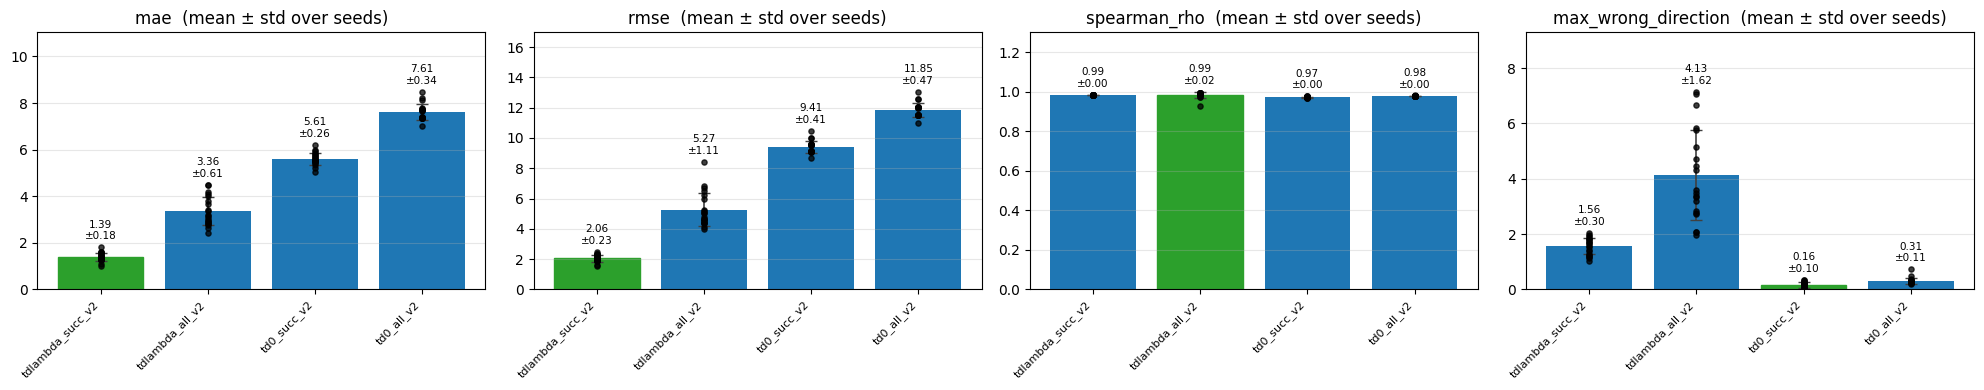

In [64]:
SHOW_COMBOS = None   # e.g. ['td0_succ_v1', 'td0_succ_v2']
HIDE_COMBOS = None
SORT_BY     = 'mae'

EVAL_RUN_NAME = 'v2'
eval_run_dir = results.new_run_dir('t2s_eval', EVAL_RUN_NAME,
                                     meta={'t2s_runs': list(T2S_RUN_LABELS.values())})

with open(os.path.join(eval_run_dir, 'eval_report.json'), 'w') as f:
    json.dump(reports, f, indent=2)

# Load the previous evaluation report for comparison
# with open(os.path.join(results.get_run_dir('t2s_eval', 'v1'), 'eval_report.json')) as f:
#     old = json.load(f)

print()
print(t2s_eval.format_report_table(
    reports, combos=SHOW_COMBOS, exclude=HIDE_COMBOS, sort_by=SORT_BY))

_ = t2s_eval.plot_combo_comparison(
    reports, combos=SHOW_COMBOS, exclude=HIDE_COMBOS, sort_by=SORT_BY,
    save_path=os.path.join(eval_run_dir, 'combo_comparison.png'))

['mc_all_v1', 'mc_succ_v1', 'mcboot_all_v1', 'mcboot_succ_v1', 'td0_all_v1', 'td0_all_v2', 'td0_succ_v1', 'td0_succ_v2', 'td0boot_all_v1', 'td0boot_succ_v1', 'tdlambda_all_v1', 'tdlambda_all_v2', 'tdlambda_succ_v1', 'tdlambda_succ_v2', 'tdlambdaboot_all_v1', 'tdlambdaboot_succ_v1']
combo                            mae              rmse         pearson_r      spearman_rhomax_wrong_directio
------------------------------------------------------------------------------------------------------------
tdlambda_all_v1        14.171 ±2.070     25.347 ±3.294      0.715 ±0.071      0.915 ±0.058     19.152 ±7.586
tdlambda_all_v2         3.358 ±0.607      5.274 ±1.109      0.978 ±0.016      0.986 ±0.015      4.127 ±1.624
tdlambdaboot_all_v1      2.544 ±0.636      4.358 ±1.424      0.973 ±0.020      0.982 ±0.018      5.599 ±2.173
td0_all_v1              6.554 ±0.263     10.073 ±0.422      0.907 ±0.006      0.966 ±0.003      0.871 ±0.361
td0_all_v2              7.614 ±0.341     11.849 ±0.472      0.

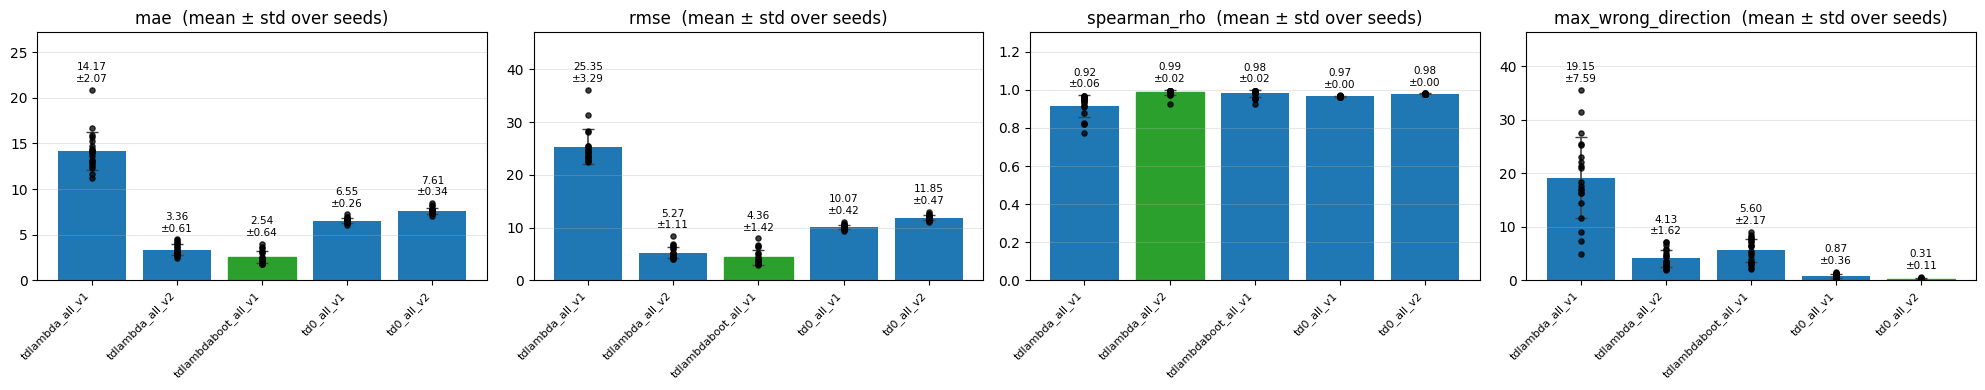

In [71]:
import json

with open(os.path.join(results.get_run_dir('t2s_eval', 'v1'), 'eval_report.json')) as f:
    rep_v1 = json.load(f)
with open(os.path.join(results.get_run_dir('t2s_eval', 'v2'), 'eval_report.json')) as f:
    rep_probe = json.load(f)

merged = {**rep_v1, **rep_probe}      # keys are already labelled
print(sorted(merged))

SHOW_COMBOS = [
    'tdlambda_all_v1',       # censor,    gamma=1.0
    'tdlambda_all_v2',       # censor,    gamma=0.99   <- the probe
    'tdlambdaboot_all_v1',   # bootstrap, gamma=0.99
    'td0_all_v1',           # censor,    gamma=1.0
    'td0_all_v2',           # censor,    gamma=0.99
]
SORT_BY = None

print(t2s_eval.format_report_table(merged, combos=SHOW_COMBOS, sort_by=SORT_BY))
_ = t2s_eval.plot_combo_comparison(
    merged, combos=SHOW_COMBOS, sort_by=SORT_BY,
    save_path=os.path.join(eval_run_dir, 'gamma_comparison.png'))

### 4c. Two sample trajectories — visual check that every model can predict

Rolls out exactly two reference trajectories (one succeeding, one failing) from the held-out policies, then overlays **every** T2S model's predictions on those *same* states. Same trajectory for all models, so any difference in the curves is the model, not the rollout.

d:\Miniconda3\envs\duke_rob\lib\site-packages\gymnasium\utils\passive_env_checker.py:34: UserWarning: WARN: A Box observation space maximum and minimum values are equal.
  logger.warn("A Box observation space maximum and minimum values are equal.")
d:\Miniconda3\envs\duke_rob\lib\site-packages\gymnasium\utils\passive_env_checker.py:157: UserWarning: WARN: The obs returned by the `reset()` method is not within the observation space.
  logger.warn(f"{pre} is not within the observation space.")
d:\Miniconda3\envs\duke_rob\lib\site-packages\gymnasium\utils\passive_env_checker.py:157: UserWarning: WARN: The obs returned by the `step()` method is not within the observation space.
  logger.warn(f"{pre} is not within the observation space.")


success: 73 steps, success_step=52
failure: 500 steps, success_step=None


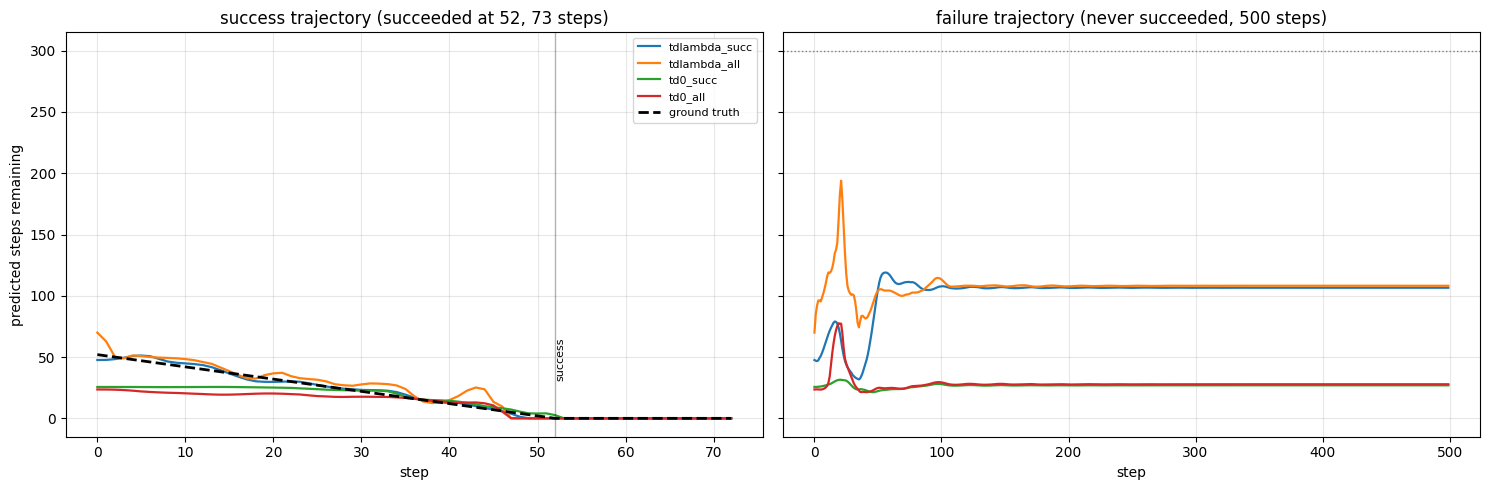

In [72]:
import t2s_eval, t2s_predict

# same held-out policies Section 4 used — must not appear in data collection
trajectories = t2s_eval.collect_eval_trajectories(eval_success_pol, eval_failure_pol, seed=500)
for scenario, traj in trajectories.items():
    print(f"{scenario}: {len(traj['obs'])} steps, success_step={traj['success_step']}")

# one predictor per combo, all evaluated on the SAME stored observations
predictors = {}
for row in summary_rows:
    method, condition = row['combo'].rsplit('_', 1)
    predictors[row['combo']] = t2s_predict.load_t2s_predictor(
        t2s_run_dir, method, condition, seed=row['best_seed'])

t2s_eval.plot_sample_trajectories(
    trajectories, predictors,
    save_path=os.path.join(eval_run_dir, 'sample_trajectories.png'));

Use the old failed policy to test the t2s

d:\!DUKE\2026_Fall\Independent_Research\grl-t2s\train_res\policy\sweep_v4_td0_succ_seed0\policy_final.zip
  succeeded=False  hand->peg=0.2144  peg_moved=True  drift=0.007383



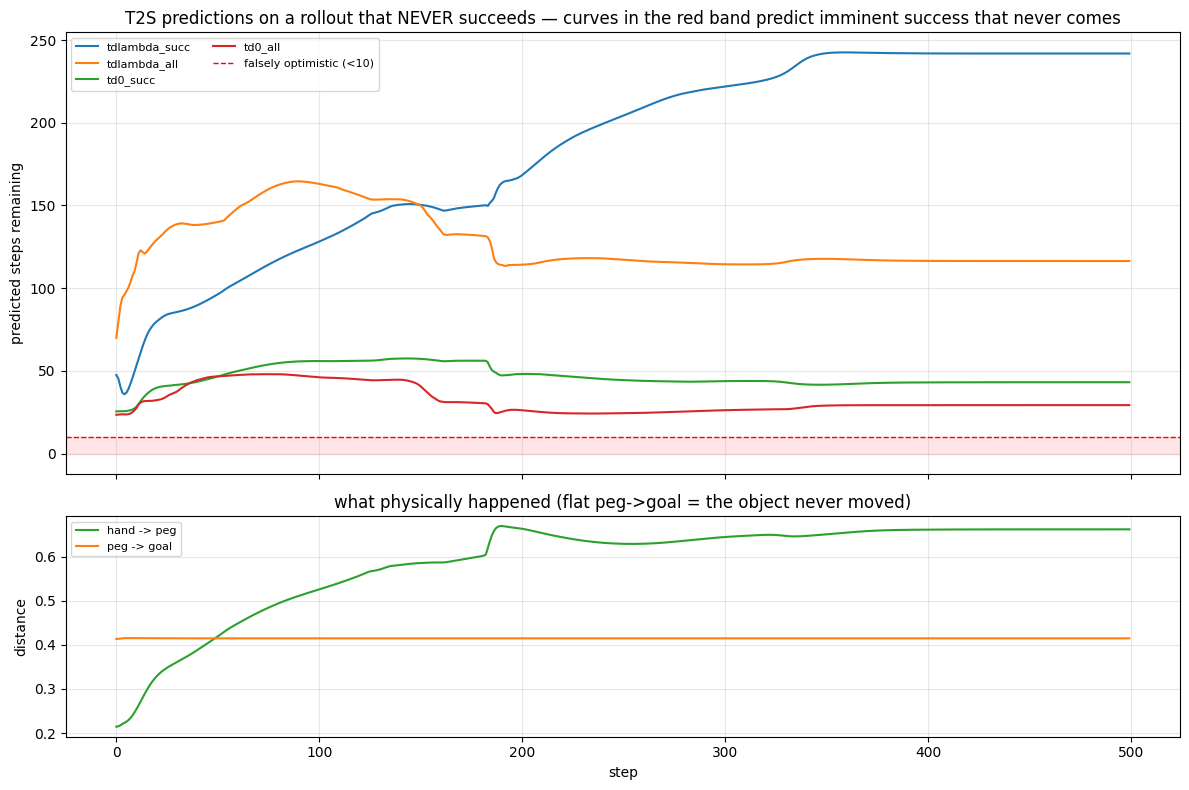

combo               min pred                     verdict
--------------------------------------------------------
td0_all                 23.6                          ok
td0_succ                25.6                          ok
tdlambda_succ           36.0                          ok
tdlambda_all            70.0                          ok


In [73]:
import numpy as np
import visualize, t2s_predict, progress

EXPLOIT_RUN   = 'sweep_v4_td0_succ_seed0'   # the policy that hovered empty-handed
EXPLOIT_CKPT  = 'policy_final.zip'
DANGER_THRESH = 10.0

exploit_dir = results.get_run_dir('policy', EXPLOIT_RUN)
policy, resolved = visualize.load_policy(EXPLOIT_CKPT, exploit_dir)

# roll out ONCE with video; every model then scores these same stored states,
# so differences between curves are the model and not the trajectory
roll = visualize.rollout(policy, predict_t2s=None, seed=0, render=True)
m = progress.compute_progress_metrics(roll['obs'], roll['success_step'])
print(f"{resolved}")
print(f"  succeeded={m['succeeded']}  hand->peg={m['min_hand_peg_distance']:.4f}  "
      f"peg_moved={m['peg_moved']}  drift={m['peg_max_drift']:.6f}\n")

predictors = {}
for row in summary_rows:
    method, cond = row['combo'].rsplit('_', 1)
    predictors[row['combo']] = t2s_predict.load_t2s_predictor(
        t2s_run_dir, method, cond, seed=row['best_seed'])

_fig, worst = visualize.plot_models_on_rollout(
    roll, predictors, danger_threshold=DANGER_THRESH,
    save_path=os.path.join(t2s_run_dir, 'false_optimism_check.png'))

print(f"{'combo':<18}{'min pred':>10}{'verdict':>28}")
print('-' * 56)
for combo, mn in sorted(worst.items(), key=lambda kv: kv[1]):
    bad = mn < DANGER_THRESH and not m['succeeded']
    print(f"{combo:<18}{mn:>10.1f}{('FALSELY OPTIMISTIC' if bad else 'ok'):>28}")

In [25]:
# burn one model's prediction into the video: watch the arm hover empty-handed
# while the number claims success is imminent
from IPython.display import Video, display

SHOW_COMBO = min(worst, key=worst.get)        # the most optimistic model
print('annotating with', SHOW_COMBO)

preds = [predictors[SHOW_COMBO](o) for o in roll['obs']]
ann = visualize.annotate_video(roll['frames'], preds, obs=roll['obs'],
                                danger_threshold=DANGER_THRESH)
path = os.path.join(t2s_run_dir, f'false_optimism_{SHOW_COMBO}.mp4')
visualize.save_video(ann, path)
display(Video(path, embed=True, width=520))

annotating with td0boot_succ


## 4b. Resume point — run this after a kernel restart

Rebuilds everything Section 5 needs (`t2s_run_dir`, `summary_rows`, `reports`) from files already on disk, so you can jump straight to downstream RL without re-running Stages 1-4. Run the first cell of the notebook (imports) first, then this, then Section 5.

In [ ]:
import json, os
import t2s_predict, t2s_eval, t2s_io

# --- point these at the runs you already completed ---
T2S_RUN_NAME  = 'v1'
EVAL_RUN_NAME = 'v1'

t2s_run_dir  = results.get_run_dir('t2s_model', T2S_RUN_NAME)
eval_run_dir = results.get_run_dir('t2s_eval', EVAL_RUN_NAME)

# rebuild summary_rows from the Stage 3 manifest (not recomputed — just read back)
manifest = t2s_io.load_manifest(t2s_run_dir)
summary_rows = [
    dict(combo=combo, mean_val_mse=info['mean_val_mse'], std_val_mse=info['std_val_mse'],
         seeds_val_mse=info['per_seed_val_mse'],
         mean_val_mse_succ_only=info['mean_val_mse_succ_only'],
         best_seed=info['best_seed'])
    for combo, info in manifest['combos'].items()
]

# rebuild reports from the Stage 4 eval report
with open(os.path.join(eval_run_dir, 'eval_report.json')) as f:
    reports = json.load(f)

print(f'resumed: {len(summary_rows)} combos from {t2s_run_dir}')
print(f'         {len(reports)} eval reports from {eval_run_dir}')
print()
print(t2s_eval.format_report_table(reports))

---
# 5. Downstream RL — configuration

**Everything downstream is configured here and nowhere else.** Sections 6-8 read these variables; none of them re-select a model or override a parameter. Change something here and re-run 5 -> 6 -> 7 -> 8.

Requires `t2s_run_dir` and `summary_rows` — from Section 3, or from the 4b resume cell after a kernel restart.

In [75]:
import t2s_predict, t2s_io

# ---------------- WHAT TO TRAIN ----------------
# (t2s run folder, combo) — folder is part of the spec, so the same combo
# from two runs can be compared
MODELS = [
    ('v1', 'tdlambdaboot_all'),   # best MAE (2.54), worst monotonicity (5.60)
    ('v2', 'td0_all'),            # worst MAE (7.61), best monotonicity (0.31)
]
SEEDS       = [0, 1, 2]
REWARD_MODE = 'difference_timed' # reward mode: 'difference_timed', 'difference', 'absolute'
TIMESTEPS   = 400_000
SWEEP_NAME  = 'sweep_v5'

# ---------------- resolve ----------------
MODEL_SPECS = {}          # label -> (run_dir, combo, t2s_seed)
PREDICTORS  = {}
for run_name, combo in MODELS:
    run_dir = results.get_run_dir('t2s_model', run_name)
    info = t2s_io.load_manifest(run_dir)['combos'][combo]   # KeyError if absent
    label = f'{combo}_{run_name}'
    method, condition = combo.rsplit('_', 1)
    PREDICTORS[label] = t2s_predict.load_t2s_predictor(
        run_dir, method, condition, seed=info['best_seed'])
    MODEL_SPECS[label] = (run_dir, combo, info['best_seed'])
    print(f"  {label:26s} seed {info['best_seed']}  gamma={info.get('gamma')}  "
          f"scheme={info.get('censor_scheme')}")

print(f"\n{len(MODELS)} model(s) x {len(SEEDS)} seed(s) = {len(MODELS)*len(SEEDS)} runs "
      f"@ {TIMESTEPS:,} steps, reward_mode={REWARD_MODE!r}")

  tdlambdaboot_all_v1        seed 0  gamma=0.99  scheme=bootstrap
  td0_all_v2                 seed 0  gamma=0.99  scheme=censor

2 model(s) x 3 seed(s) = 6 runs @ 400,000 steps, reward_mode='difference_timed'


---
# 6. Reward preview (no training)

Replays two reference trajectories through the reward arithmetic for **exactly the models configured in Section 5**, so you see the real reward signal before spending compute.

**`return_gap` is the go/no-go gate**: success-trajectory return minus failure-trajectory return. If a reward gives similar returns to a trajectory that succeeds and one that never does, no training budget can make RL prefer success.

In [76]:
import reward_preview, t2s_eval

# collect the two reference trajectories if 4c hasn't already (self-contained)
if 'trajectories' not in dir():
    trajectories = t2s_eval.collect_eval_trajectories(eval_success_pol, eval_failure_pol, seed=500)
for scenario, traj in trajectories.items():
    print(f"{scenario}: {len(traj['obs'])} steps, success_step={traj['success_step']}")
print()

# previews BOTH reward modes so you can sanity-check the Section 5 choice
preview = reward_preview.preview_reward(trajectories, PREDICTORS,
                                         reward_modes=('absolute', 'difference'))
print(reward_preview.format_preview_table(preview))
print()
print('return gap : success return - failure return  (want LARGE POSITIVE)')
print('dead% s/f  : fraction of ~zero-reward steps    (want LOW, esp. failure)')
print('align      : Spearman(reward, peg-dist reduction) (want POSITIVE)')

chosen = [(c, m) for (c, m) in preview if m == REWARD_MODE]
print(f'\n--- configured mode ({REWARD_MODE}) ---')
for key in chosen:
    gap = preview[key].get('return_gap')
    verdict = 'OK' if (gap or 0) > 0 else 'NEGATIVE GAP — reward prefers the failing trajectory'
    print(f'  {key[0]:16s} return_gap={gap:,.1f}  {verdict}')

success: 73 steps, success_step=52
failure: 500 steps, success_step=None

combo           mode         return gap   succ ret   fail ret     dead% s/f   align
-----------------------------------------------------------------------------------
tdlambdaboot_all_v1absolute        57796.9    -1461.5   -59258.3     0.35/0.00    0.08
td0_all_v2      absolute        13347.5     -827.4   -14174.9     0.35/0.00    0.08
tdlambdaboot_all_v1difference        119.6       65.8      -53.9     0.33/0.10    0.06
td0_all_v2      difference         27.8       23.6       -4.3     0.33/0.31    0.25

return gap : success return - failure return  (want LARGE POSITIVE)
dead% s/f  : fraction of ~zero-reward steps    (want LOW, esp. failure)
align      : Spearman(reward, peg-dist reduction) (want POSITIVE)

--- configured mode (difference_timed) ---


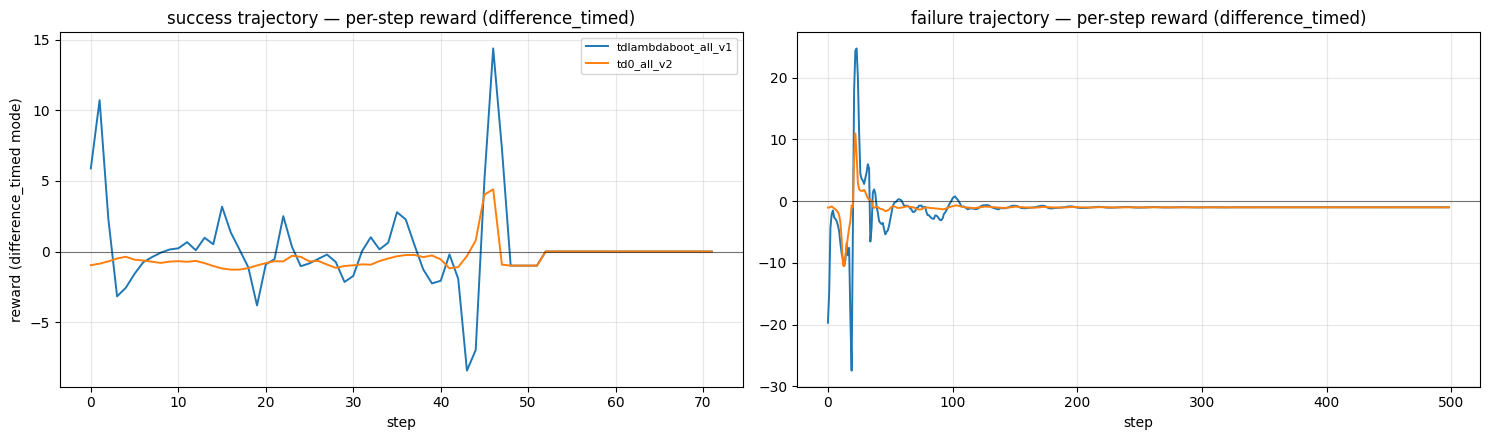

In [77]:
# per-step reward curves — a flat line at ANY level means no gradient
reward_preview.plot_reward_preview(
    trajectories, PREDICTORS, reward_mode=REWARD_MODE,
    save_path=os.path.join(eval_run_dir, f'reward_preview_{REWARD_MODE}.png'));

---
# 7. Train

Trains one policy per (combo, seed) from the Section 5 config. Resumable: a run whose `eval_history.json` already exists is loaded rather than retrained, so you can extend `SEEDS` later and only pay for the new ones.

In [78]:
import json
import policy_train

sweep_results = {}
for label, (run_dir, combo, t2s_seed) in MODEL_SPECS.items():
    res = policy_train.run_sweep(
        run_dir, results, combos=[combo], seeds=SEEDS, t2s_seeds={combo: t2s_seed},
        sweep_name=f'{SWEEP_NAME}_{label}',      # keeps run dirs distinct
        reward_mode=REWARD_MODE, total_timesteps=TIMESTEPS, skip_existing=True,
        ckpt_freq=10_000, eval_freq=10_000, n_eval_episodes=3)
    sweep_results.update({(label, sd): h for (_c, sd), h in res.items()})

sweep_rows = policy_train.summarize_sweep(sweep_results)
print()
print(policy_train.format_sweep_table(sweep_rows))

sweep_dir = results.new_run_dir('policy', SWEEP_NAME,
                                  meta={'kind': 'sweep_summary', 'models': MODELS,
                                        'seeds': SEEDS, 'reward_mode': REWARD_MODE,
                                        'timesteps': TIMESTEPS})
with open(os.path.join(sweep_dir, 'sweep_summary.json'), 'w') as f:
    json.dump({'rows': sweep_rows,
                'raw': {f'{c}|{s}': h for (c, s), h in sweep_results.items()}}, f, indent=2)
print(f'\nsaved to {sweep_dir}')

[1/3] sweep_v5_tdlambdaboot_all_v1_tdlambdaboot_all_seed0: training 400,000 steps


d:\Miniconda3\envs\duke_rob\lib\site-packages\gymnasium\utils\passive_env_checker.py:34: UserWarning: WARN: A Box observation space maximum and minimum values are equal.
  logger.warn("A Box observation space maximum and minimum values are equal.")
d:\Miniconda3\envs\duke_rob\lib\site-packages\gymnasium\utils\passive_env_checker.py:157: UserWarning: WARN: The obs returned by the `reset()` method is not within the observation space.
  logger.warn(f"{pre} is not within the observation space.")
d:\Miniconda3\envs\duke_rob\lib\site-packages\gymnasium\utils\passive_env_checker.py:157: UserWarning: WARN: The obs returned by the `step()` method is not within the observation space.
  logger.warn(f"{pre} is not within the observation space.")


[ckpt] saved d:\!DUKE\2026_Fall\Independent_Research\grl-t2s\train_res\policy\sweep_v5_tdlambdaboot_all_v1_tdlambdaboot_all_seed0\policy_10002.zip
[eval @ 10002] succ=0.00 hand->peg=0.1754 peg->goal=0.4135 peg_moved=1.0 ctrl=0.0
[ckpt] saved d:\!DUKE\2026_Fall\Independent_Research\grl-t2s\train_res\policy\sweep_v5_tdlambdaboot_all_v1_tdlambdaboot_all_seed0\policy_20004.zip
[eval @ 20004] succ=0.00 hand->peg=0.1849 peg->goal=0.4135 peg_moved=1.0 ctrl=0.0
[ckpt] saved d:\!DUKE\2026_Fall\Independent_Research\grl-t2s\train_res\policy\sweep_v5_tdlambdaboot_all_v1_tdlambdaboot_all_seed0\policy_30000.zip
[eval @ 30000] succ=0.00 hand->peg=0.1814 peg->goal=0.4135 peg_moved=1.0 ctrl=0.0
[ckpt] saved d:\!DUKE\2026_Fall\Independent_Research\grl-t2s\train_res\policy\sweep_v5_tdlambdaboot_all_v1_tdlambdaboot_all_seed0\policy_40002.zip
[eval @ 40002] succ=0.00 hand->peg=0.1827 peg->goal=0.4135 peg_moved=1.0 ctrl=0.0
[ckpt] saved d:\!DUKE\2026_Fall\Independent_Research\grl-t2s\train_res\policy\sweep_

C:\Users\Allen\AppData\Local\Temp\ipykernel_35548\3980067232.py:40: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(combos_plot, rotation=20, ha='right')


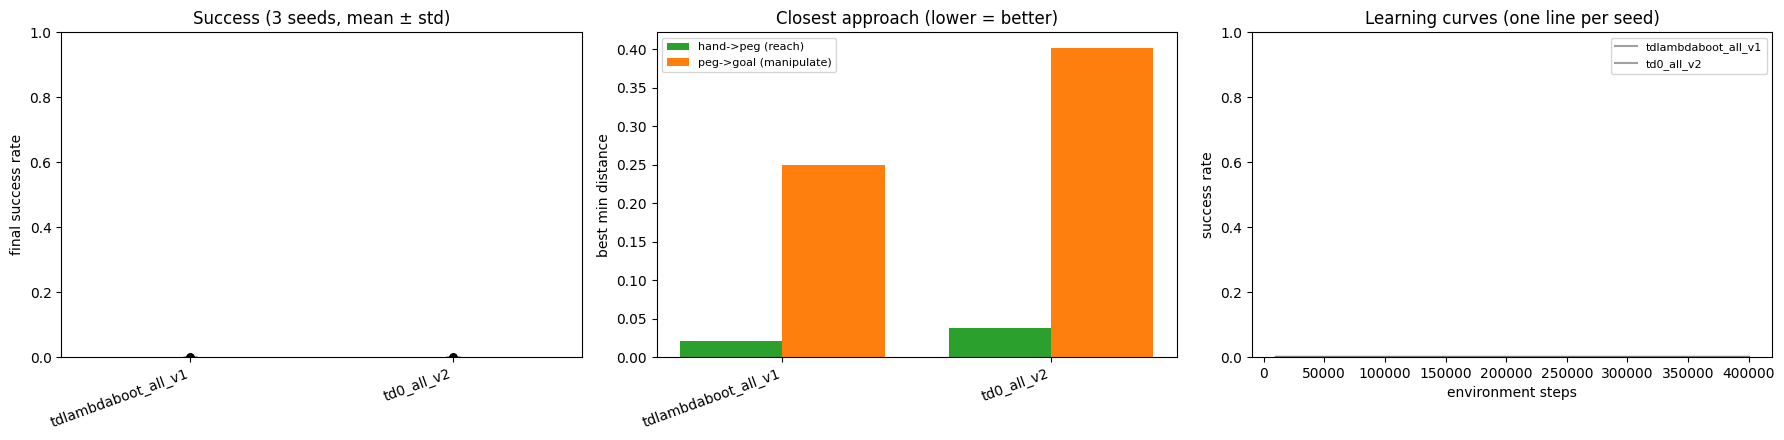

In [79]:
import matplotlib.pyplot as plt
import numpy as np

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 4.5))
combos_plot = [r['combo'] for r in sweep_rows]

# success rate, mean +/- std across seeds, individual seeds as dots
ax1.bar(combos_plot, [r['mean_final_success'] for r in sweep_rows],
         yerr=[r['std_final_success'] for r in sweep_rows], capsize=5, color='tab:blue')
for i, r in enumerate(sweep_rows):
    ax1.scatter([i]*len(r['per_seed_final_success']), r['per_seed_final_success'],
                 color='black', zorder=3, s=25)
ax1.set_ylabel('final success rate'); ax1.set_ylim(0, 1)
ax1.set_title(f'Success ({len(SEEDS)} seeds, mean ± std)')

# REACH phase (hand->peg) alongside MANIPULATION phase (peg->goal).
# peg->goal is blind to reaching: an arm that touches the peg but never grasps
# leaves the peg at its reset position, so peg->goal stays constant either way.
x = np.arange(len(combos_plot)); w = 0.38
hand = [r.get('best_min_hand_peg_distance') or 0 for r in sweep_rows]
peg  = [r.get('best_min_peg_goal_distance') or 0 for r in sweep_rows]
ax2.bar(x - w/2, hand, w, label='hand->peg (reach)', color='tab:green')
ax2.bar(x + w/2, peg,  w, label='peg->goal (manipulate)', color='tab:orange')
ax2.set_xticks(x)
ax2.set_ylabel('best min distance'); ax2.set_title('Closest approach (lower = better)')
ax2.legend(fontsize=8)

# learning curves, one line per (combo, seed)
colors = dict(zip(COMBOS, ['tab:blue','tab:orange','tab:green','tab:red','tab:purple']))
for (combo, sd), history in sweep_results.items():
    if not history:
        continue
    ax3.plot([h['step'] for h in history], [h['success_rate'] for h in history],
              color=colors.get(combo, 'gray'), alpha=0.75,
              label=combo if sd == SEEDS[0] else None)
ax3.set_xlabel('environment steps'); ax3.set_ylabel('success rate'); ax3.set_ylim(0, 1)
ax3.set_title('Learning curves (one line per seed)'); ax3.legend(fontsize=8)

for ax in (ax1, ax2):
    ax.set_xticklabels(combos_plot, rotation=20, ha='right')
plt.tight_layout()
plt.savefig(os.path.join(sweep_dir, 'sweep_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()

In [86]:
import json, glob, os
import numpy as np
import progress
from env_utils import make_fixed_scene_env

# --- baseline: distance at reset, and under a random policy ---
env = make_fixed_scene_env()
obs, _ = env.reset(seed=0)
print(f"peg-goal distance at reset:        {progress.peg_goal_distance(obs):.4f}")

rand_obs = [obs.copy()]
for _ in range(500):
    obs, _, term, trunc, _ = env.step(env.action_space.sample())
    rand_obs.append(obs.copy())
    if term or trunc: break
env.close()
m = progress.compute_progress_metrics(np.array(rand_obs), None)
print(f"random policy min distance:        {m['min_peg_goal_distance']:.4f}")
print(f"random policy obs_movement:        {m['obs_movement']:.1f}")
print(f"random policy achieved control:    {m.get('achieved_control')}")

# --- what your trained runs actually recorded ---
print("\nper-run final eval:")
for path in sorted(glob.glob(os.path.join('train_res', 'policy', f'{SWEEP_NAME}_*', 'eval_history.json'))):
    h = json.load(open(path))
    if not h: continue
    last = h[-1]
    name = os.path.basename(os.path.dirname(path))
    print(f"  {name:34s} n_evals={len(h):3d} "
          f"min_d={last.get('mean_min_peg_goal_distance')} "
          f"ctrl={last.get('control_rate')} "
          f"move={last.get('mean_obs_movement')}")

peg-goal distance at reset:        0.4135
random policy min distance:        0.4135
random policy obs_movement:        15.5
random policy achieved control:    False

per-run final eval:
  sweep_v5_td0_all_v2_td0_all_seed0  n_evals= 40 min_d=0.413543889020503 ctrl=0.0 move=11.316006824442852
  sweep_v5_td0_all_v2_td0_all_seed1  n_evals= 40 min_d=0.4120507547662511 ctrl=1.0 move=2.570178642821233
  sweep_v5_td0_all_v2_td0_all_seed2  n_evals= 40 min_d=0.413543889020503 ctrl=0.0 move=6.826098289409387
  sweep_v5_tdlambdaboot_all_v1_tdlambdaboot_all_seed0 n_evals= 40 min_d=0.413543889020503 ctrl=0.0 move=22.562794348472732
  sweep_v5_tdlambdaboot_all_v1_tdlambdaboot_all_seed1 n_evals= 40 min_d=0.413543889020503 ctrl=1.0 move=24.478396876634335
  sweep_v5_tdlambdaboot_all_v1_tdlambdaboot_all_seed2 n_evals= 40 min_d=0.2764522886055204 ctrl=1.0 move=30.117462935679402


In [87]:
import json, glob, os
for path in sorted(glob.glob(os.path.join('train_res','policy','sweep_v2_*','eval_history.json'))):
    h = json.load(open(path))
    if not h: continue
    name = os.path.basename(os.path.dirname(path))
    best_ctrl = max((e.get('control_rate') or 0) for e in h)
    best_d = min((e.get('mean_min_peg_goal_distance') or 9e9) for e in h)
    print(f"{name:36s} best_ctrl={best_ctrl:.2f} best_min_d={best_d:.4f}")

sweep_v2_td0_all_seed0               best_ctrl=1.00 best_min_d=0.2949
sweep_v2_td0_all_seed1               best_ctrl=1.00 best_min_d=0.3436
sweep_v2_td0_all_seed2               best_ctrl=1.00 best_min_d=0.3854
sweep_v2_td0_succ_seed0              best_ctrl=0.00 best_min_d=0.4135
sweep_v2_td0_succ_seed1              best_ctrl=0.00 best_min_d=0.4135
sweep_v2_td0_succ_seed2              best_ctrl=0.00 best_min_d=0.4135


### 7b. Progress comparison across runs

Bar comparison of every model-independent progress metric, across any set of runs.

**Calibrate first.** Success does not occur at peg-goal distance 0 — `PEG_POS_IDX` tracks the peg's body centre while `GOAL_POS_IDX` is the hole, so at insertion the centre is still offset by roughly half the peg length. Measured here: ~0.4135 at reset, ~0.192 at success. Raw distance bars are misleading without those reference points, which is why the third panel normalizes to a 0-1 progress fraction.

6 run(s) found

run                                 hand->peg  peg->goal  progress   moved   succ
---------------------------------------------------------------------------------
sweep_v5_td0_all_v2_td0_all_seed0      0.0379     0.4126        0%    1.00   0.00
sweep_v5_td0_all_v2_td0_all_seed1      0.0536     0.4021        5%    1.00   0.00
sweep_v5_td0_all_v2_td0_all_seed2      0.0716     0.4135        0%    1.00   0.00
sweep_v5_tdlambdaboot_all_v1_tdlambdaboot_all_seed0     0.0211     0.2497       74%    1.00   0.00
sweep_v5_tdlambdaboot_all_v1_tdlambdaboot_all_seed1     0.0213     0.2788       61%    1.00   0.00
sweep_v5_tdlambdaboot_all_v1_tdlambdaboot_all_seed2     0.0215     0.2694       65%    1.00   0.00


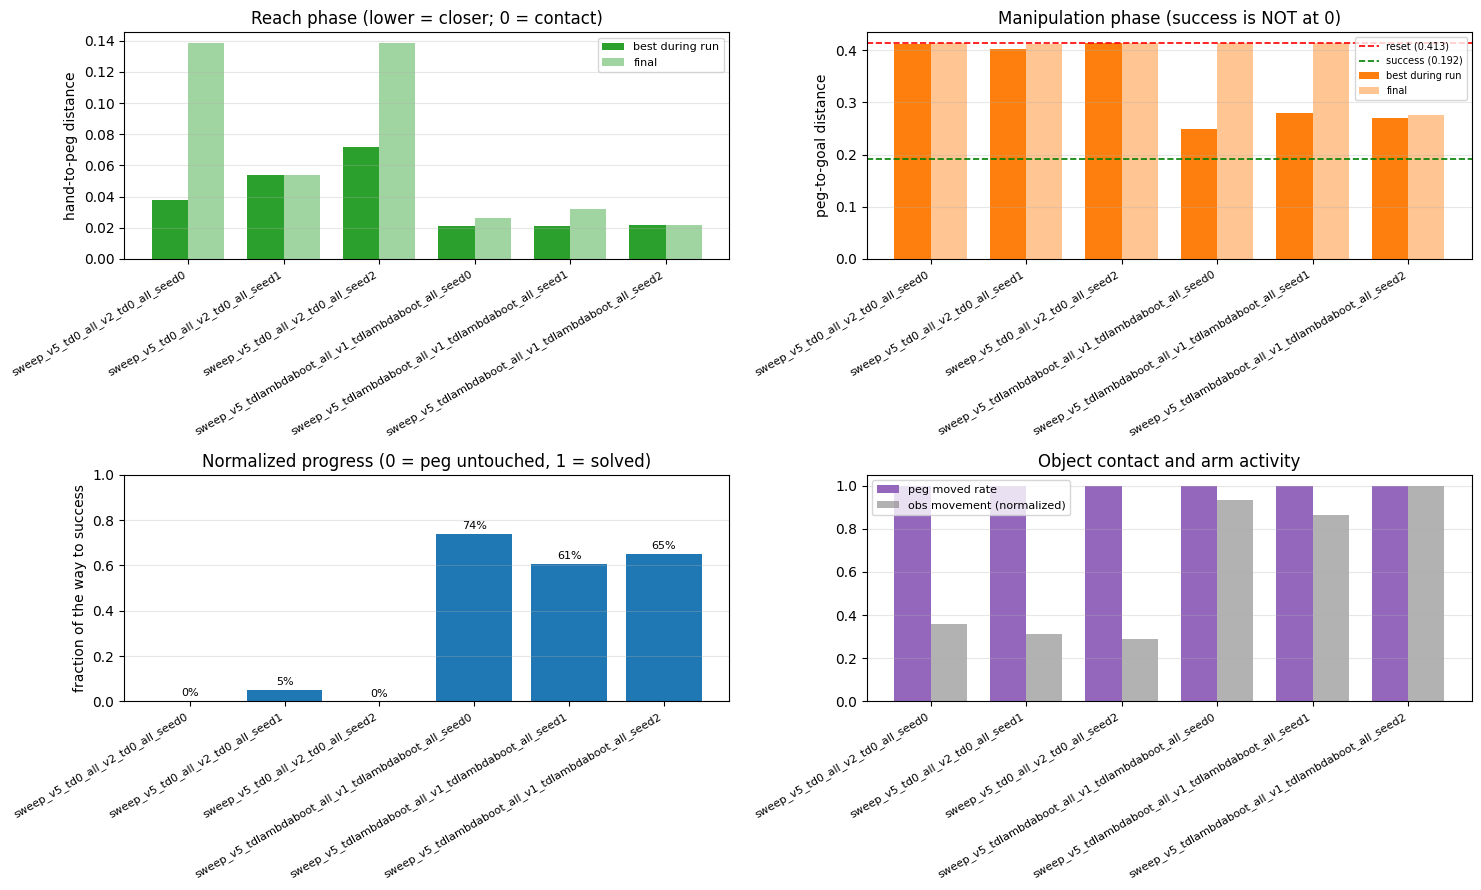

In [89]:
import progress

# --- calibration: measure rather than assume ---
RESET_DIST   = 0.4135     # peg-goal distance at env reset
SUCCESS_DIST = 0.192      # peg-goal distance at the success frame

RUN_GLOB = os.path.join('train_res', 'policy', 'sweep_v5_*')   # any glob
histories = progress.load_run_histories(RUN_GLOB)
print(f'{len(histories)} run(s) found\n')
print(progress.format_progress_table(histories, RESET_DIST, SUCCESS_DIST))

_ = progress.plot_progress_comparison(
    histories, reset_distance=RESET_DIST, success_distance=SUCCESS_DIST,
    save_path=os.path.join('train_res', 'policy', 'progress_comparison.png'))

---
# 8. Check a trained policy

Load any policy produced above (or any other checkpoint) and look at what it actually does: rollout video, and the T2S prediction curve it was trained against.

Defaults to the best run from Section 7; override `CHECK_RUN` / `CHECK_CKPT` to inspect anything else, including expert checkpoints.

### Search for the best checkpoint

In [80]:
import json, glob, os
for path in sorted(glob.glob(os.path.join('train_res','policy','sweep_v5*','eval_history.json'))):
    h = json.load(open(path))
    name = os.path.basename(os.path.dirname(path))
    peak = max(h, key=lambda e: (e.get('control_rate') or 0))
    print(f"\n{name}")
    print(f"  peak ctrl={peak.get('control_rate')} at step {peak['step']}, "
          f"min_d={peak.get('mean_min_peg_goal_distance')}")
    print(f"  final   ctrl={h[-1].get('control_rate')} at step {h[-1]['step']}")
    # trace when control was held
    held = [e['step'] for e in h if (e.get('control_rate') or 0) > 0]
    print(f"  control achieved at steps: {held[:10]}{'...' if len(held)>10 else ''} ({len(held)}/{len(h)} evals)")


sweep_v5_td0_all_v2_td0_all_seed0
  peak ctrl=1.0 at step 260004, min_d=0.41264987530229424
  final   ctrl=0.0 at step 400002
  control achieved at steps: [260004, 300000] (2/40 evals)

sweep_v5_td0_all_v2_td0_all_seed1
  peak ctrl=1.0 at step 330000, min_d=0.41239501349074564
  final   ctrl=1.0 at step 400002
  control achieved at steps: [330000, 390000, 400002] (3/40 evals)

sweep_v5_td0_all_v2_td0_all_seed2
  peak ctrl=1.0 at step 210000, min_d=0.413543889020503
  final   ctrl=0.0 at step 400002
  control achieved at steps: [210000, 220002, 230004, 240000, 250002, 260004, 270000, 280002, 290004, 300000]... (17/40 evals)

sweep_v5_tdlambdaboot_all_v1_tdlambdaboot_all_seed0
  peak ctrl=1.0 at step 110004, min_d=0.413543889020503
  final   ctrl=0.0 at step 400002
  control achieved at steps: [110004, 120000, 130002, 140004, 150000, 160002, 170004, 190002, 200004, 210000]... (27/40 evals)

sweep_v5_tdlambdaboot_all_v1_tdlambdaboot_all_seed1
  peak ctrl=1.0 at step 40002, min_d=0.413543

In [81]:
import sys
sys.modules.pop('progress', None)
import progress
print('has new metrics:', 'min_hand_peg_distance' in progress.compute_progress_metrics.__doc__ or
      hasattr(progress, 'hand_peg_distance'))

has new metrics: True


In [ ]:
import glob, os
import numpy as np
import visualize, progress

for run in sorted(glob.glob(os.path.join('train_res','policy','sweep_v5_tdlambdaboot_all_v1_tdlambdaboot_all_seed1'))):
    name = os.path.basename(run)
    for ckpt in ('policy_400002.zip',):   # add a peak-step ckpt here too
        path = os.path.join(run, ckpt)
        if not os.path.exists(path):
            continue
        policy, _ = visualize.load_policy(ckpt, run)
        for sd in (0, 1):
            r = visualize.rollout(policy, predict_t2s=None, seed=sd)
            m = progress.compute_progress_metrics(r['obs'], r['success_step'])
            print(f"{name} {ckpt} seed{sd}: "
                  f"hand->peg={m['min_hand_peg_distance']:.4f} "
                  f"peg_moved={m['peg_moved']} drift={m['peg_max_drift']:.6f} "
                  f"ctrl_detector={m['achieved_control']}")

d:\Miniconda3\envs\duke_rob\lib\site-packages\gymnasium\utils\passive_env_checker.py:34: UserWarning: WARN: A Box observation space maximum and minimum values are equal.
  logger.warn("A Box observation space maximum and minimum values are equal.")
d:\Miniconda3\envs\duke_rob\lib\site-packages\gymnasium\utils\passive_env_checker.py:157: UserWarning: WARN: The obs returned by the `reset()` method is not within the observation space.
  logger.warn(f"{pre} is not within the observation space.")
d:\Miniconda3\envs\duke_rob\lib\site-packages\gymnasium\utils\passive_env_checker.py:157: UserWarning: WARN: The obs returned by the `step()` method is not within the observation space.
  logger.warn(f"{pre} is not within the observation space.")


sweep_v5_tdlambdaboot_all_v1_tdlambdaboot_all_seed0 policy_110004.zip seed0: hand->peg=0.1541 peg_moved=True drift=0.031218 ctrl_detector=True
sweep_v5_tdlambdaboot_all_v1_tdlambdaboot_all_seed0 policy_110004.zip seed1: hand->peg=0.1541 peg_moved=True drift=0.031218 ctrl_detector=True


loaded: d:\!DUKE\2026_Fall\Independent_Research\grl-t2s\train_res\policy\sweep_v5_td0_all_v2_td0_all_seed1\policy_final.zip
  seed 0: FAILED (ran 500 steps without success) | T2S start=65.8 end=110.1 min=65.8 max_upward_jump=19.86


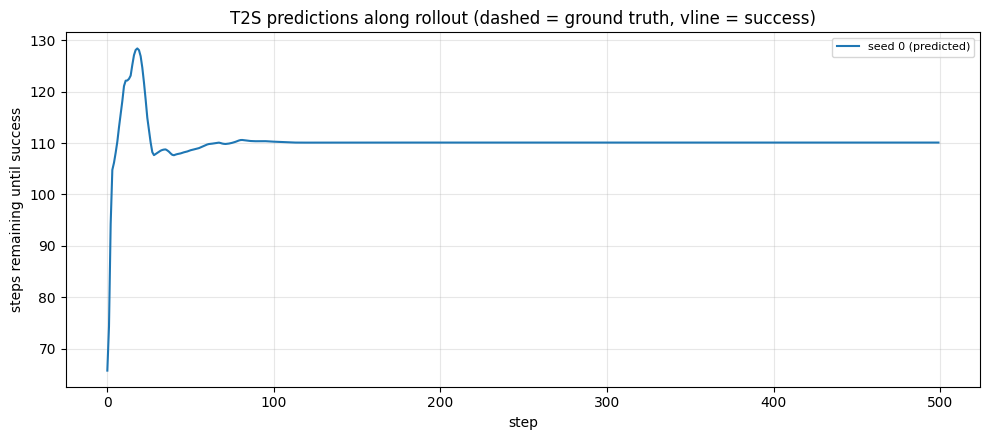

  seed 0: min_peg_goal_dist=0.4135 control=False obs_movement=2.71


In [103]:
import visualize

# defaults to the top-ranked combo from Section 7, first seed
CHECK_COMBO = sweep_rows[0]['combo'] if 'sweep_rows' in dir() and sweep_rows else COMBOS[0]
CHECK_SEED  = SEEDS[0]
CHECK_RUN  = 'sweep_v5_td0_all_v2_td0_all_seed1'   # from list_runs
CHECK_CKPT  = 'policy_final.zip'      # or 'policy_<step>.zip'
SEEDS_TO_VIEW = [0]
RENDER_VIDEO  = True

check_dir = results.get_run_dir('policy', CHECK_RUN)
policy, resolved = visualize.load_policy(CHECK_CKPT, check_dir)
print('loaded:', resolved)
# print('t2s reward model:', CHECK_COMBO, f'(seed {T2S_SEEDS[CHECK_COMBO]})')

predict_fn = PREDICTORS[CHECK_COMBO]   # the exact reward the policy trained against

rollouts = []
for sd in SEEDS_TO_VIEW:
    r = visualize.rollout(policy, predict_t2s=predict_fn, seed=sd, render=RENDER_VIDEO)
    rollouts.append(r)
    print(f'  seed {sd}: {visualize.summarize_rollout(r)}')
    if RENDER_VIDEO and r['frames']:
        visualize.save_video(r['frames'], os.path.join(check_dir, f'check_seed{sd}.mp4'))

visualize.plot_rollouts(rollouts, labels=[f'seed {s}' for s in SEEDS_TO_VIEW],
                         save_path=os.path.join(check_dir, 'check_t2s_curves.png'))

# model-independent progress, same metric the sweep table ranks on
import progress
for sd, r in zip(SEEDS_TO_VIEW, rollouts):
    m = progress.compute_progress_metrics(r['obs'], r['success_step'])
    print(f"  seed {sd}: min_peg_goal_dist={m['min_peg_goal_distance']:.4f} "
          f"control={m.get('achieved_control')} obs_movement={m['obs_movement']:.2f}")

In [ ]:
from IPython.display import Video, display

video_path = os.path.join(check_dir, f'check_seed{SEEDS_TO_VIEW[0]}.mp4')
print(video_path)
display(Video(video_path, embed=True, width=480)) if os.path.exists(video_path) \
    else print('no video — set RENDER_VIDEO=True')

Side Testing

In [95]:
# ---- gripper sensitivity probe (robust version) ----
# The earlier one-state probe used a guessed perturbation (+1.0) on a single
# reset observation. This measures the ACTUAL gripper range in the dataset and
# sweeps it across MANY real states, so the result isn't an artifact of one
# made-up value at one point in state space.
import numpy as np
import t2s_predict, t2s_io
from config import GRIPPER_IDX, HAND_POS_IDX, PEG_POS_IDX

# --- models: loaded explicitly here so this cell stands alone ---
PROBE_MODELS = [
    ('v1', 'tdlambdaboot_all'),
    ('v2', 'td0_all'),
]
probe_fns = {}
for run_name, combo in PROBE_MODELS:
    d = results.get_run_dir('t2s_model', run_name)
    info = t2s_io.load_manifest(d)['combos'][combo]
    m, c = combo.rsplit('_', 1)
    probe_fns[f'{combo}_{run_name}'] = t2s_predict.load_t2s_predictor(
        d, m, c, seed=info['best_seed'])

# --- what does the gripper dimension actually look like? ---
d = np.load(os.path.join(data_run_dir, 'dataset.npz'))
X, y = d['X'], d['y_steps']
g = X[:, GRIPPER_IDX]
g_lo, g_hi = float(np.percentile(g, 1)), float(np.percentile(g, 99))
print(f"gripper dim {GRIPPER_IDX}: min={g.min():.3f} max={g.max():.3f} "
      f"1st pct={g_lo:.3f} 99th pct={g_hi:.3f} mean={g.mean():.3f}")

# --- sample REAL states, grouped by how close the hand is to the peg ---
hand_peg = np.linalg.norm(X[:, HAND_POS_IDX] - X[:, PEG_POS_IDX], axis=1)
groups = {
    'far  (hand>0.3)':  np.flatnonzero(hand_peg > 0.3),
    'mid  (0.1-0.3)':   np.flatnonzero((hand_peg > 0.1) & (hand_peg <= 0.3)),
    'near (hand<0.05)': np.flatnonzero(hand_peg <= 0.05),
}
rng = np.random.default_rng(0)
N = 200

print(f"\n{'model':<24}{'region':<18}{'pred@open':>11}{'pred@closed':>13}{'delta':>9}")
print('-' * 76)
for label, fn in probe_fns.items():
    for gname, idx in groups.items():
        if len(idx) == 0:
            continue
        sample = rng.choice(idx, size=min(N, len(idx)), replace=False)
        opened, closed = [], []
        for i in sample:
            o = X[i].copy(); o[GRIPPER_IDX] = g_lo; opened.append(fn(o))
            c = X[i].copy(); c[GRIPPER_IDX] = g_hi; closed.append(fn(c))
        o_m, c_m = float(np.mean(opened)), float(np.mean(closed))
        print(f"{label:<24}{gname:<18}{o_m:>11.2f}{c_m:>13.2f}{c_m - o_m:>+9.2f}")

gripper dim 3: min=0.262 max=1.000 1st pct=0.286 99th pct=1.000 mean=0.416

model                   region              pred@open  pred@closed    delta
----------------------------------------------------------------------------
tdlambdaboot_all_v1     far  (hand>0.3)        146.17       167.05   +20.88
tdlambdaboot_all_v1     mid  (0.1-0.3)         123.22       125.25    +2.02
tdlambdaboot_all_v1     near (hand<0.05)        10.25        19.16    +8.92
td0_all_v2              far  (hand>0.3)         42.27        46.68    +4.41
td0_all_v2              mid  (0.1-0.3)          34.06        35.99    +1.93
td0_all_v2              near (hand<0.05)         5.67         7.37    +1.70
